## lesson 24

### dbcan k-means иерархическая кластеризация. для всех pca. анализ и интерпретация лучшего метода

In [133]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
import warnings
warnings.filterwarnings('ignore')
import numpy as np
from sklearn.decomposition import PCA

In [134]:
df = pd.read_csv('C:/3курс/DS/CCGENERAL.csv')
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [135]:
print(df.isna().sum())

CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64


In [136]:
df['MINIMUM_PAYMENTS'] = df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].median())

In [137]:
df['CREDIT_LIMIT'] = df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].median())

In [138]:
df = df.drop(columns=['CUST_ID'])

In [139]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)


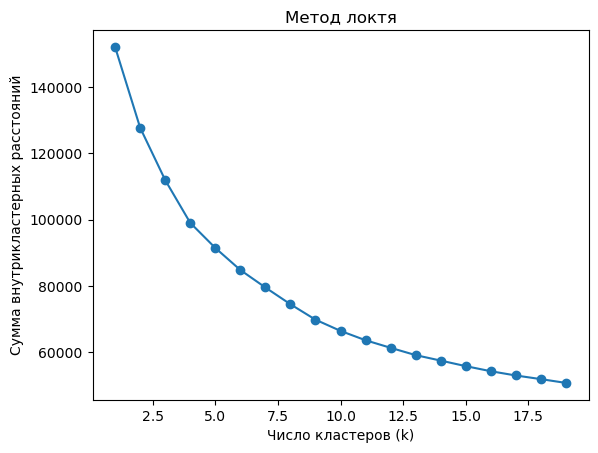

In [140]:
inertia = []
for k in range(1, 20):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=15)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 20), inertia, marker='o')
plt.title("Метод локтя")
plt.xlabel("Число кластеров (k)")
plt.ylabel("Сумма внутрикластерных расстояний")
plt.show()

In [141]:


kmeans = KMeans(n_clusters = 5, random_state = 42, n_init = 'auto')
kmeans_labels = kmeans.fit_predict(X_scaled)
#print(f"MSE: {kmeans.inertia_}")

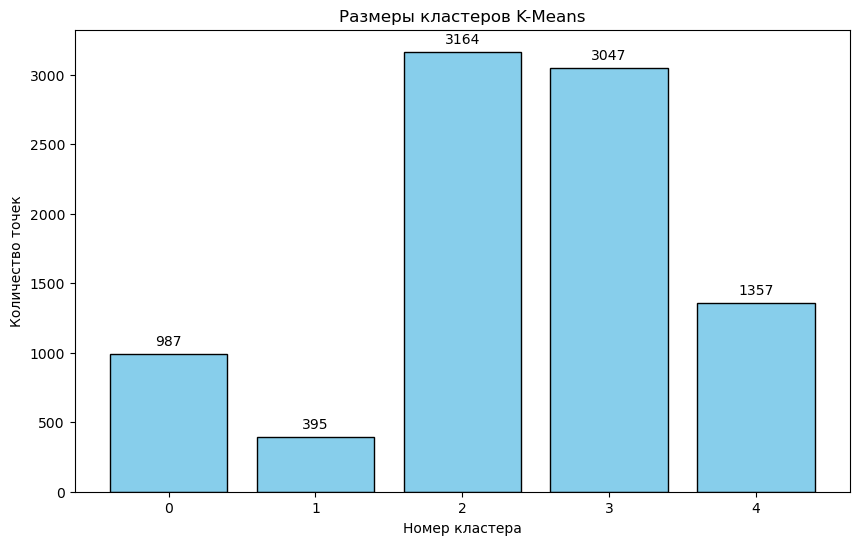

In [142]:
cluster_counts = pd.Series(kmeans_labels).value_counts().sort_index()

plt.figure(figsize=(10, 6))

x_positions = np.arange(len(cluster_counts))  # или cluster_counts.index.astype(int)
colors = ['skyblue' for _ in cluster_counts.index]
plt.bar(cluster_counts.index, cluster_counts.values, color=colors, edgecolor='black')



plt.title('Размеры кластеров K-Means')
plt.xlabel('Номер кластера')
plt.ylabel('Количество точек')

for i, v in enumerate(cluster_counts.values):
    plt.text(cluster_counts.index[i], v + max(cluster_counts.values)*0.02, str(v), ha='center')

plt.show()

<Figure size 1200x600 with 0 Axes>

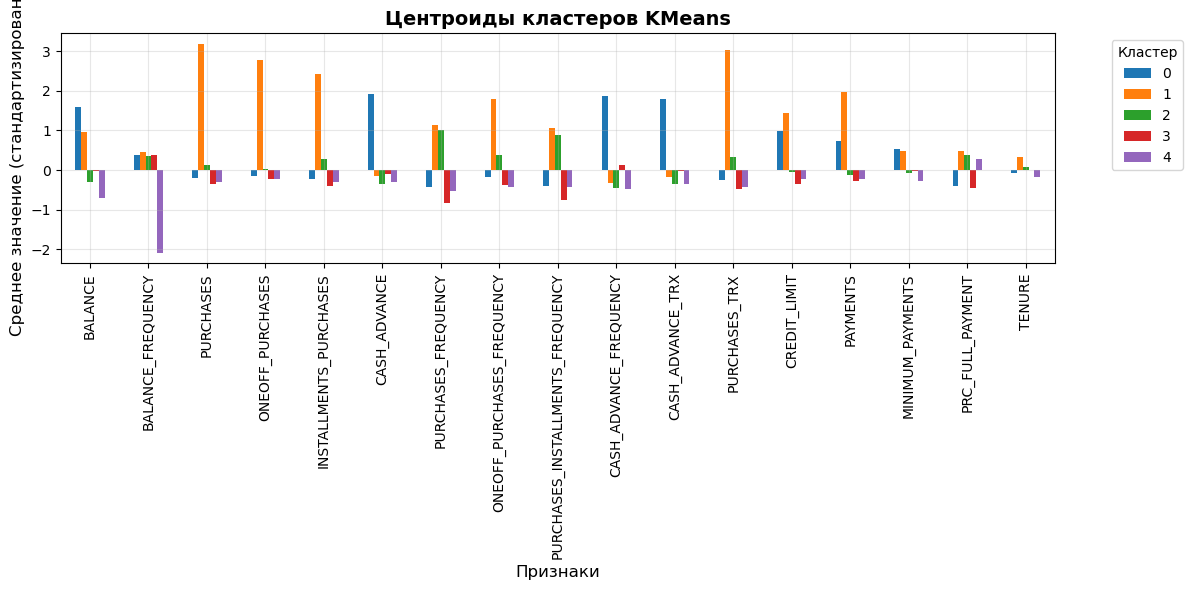

In [143]:
# Визуализация центроидов кластеров KMeans
plt.figure(figsize=(12, 6))
features = df.columns.tolist() 
centroids = kmeans.cluster_centers_

centroids_df = pd.DataFrame(centroids, columns=features)

centroids_df.T.plot(kind='bar', figsize=(12, 6))  # Транспонируем для лучшей визуализации
plt.title('Центроиды кластеров KMeans', fontsize=14, fontweight='bold')
plt.xlabel('Признаки', fontsize=12)
plt.ylabel('Среднее значение (стандартизированное)', fontsize=12)
plt.legend(title='Кластер', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [144]:
from sklearn.metrics import silhouette_score
sil_kmeans = silhouette_score(X_scaled, kmeans_labels)

In [145]:
print(sil_kmeans)

0.19256596919095403


In [146]:

for eps in [0.8, 1.0, 1.2, 1.5, 2.0]:
    for min_samples in [3, 5, 10]:
        dbscan_test = DBSCAN(eps=eps, min_samples=min_samples)
        labels_test = dbscan_test.fit_predict(X_scaled)
        n_clusters = len(set(labels_test)) - (1 if -1 in labels_test else 0)
        n_noise = list(labels_test).count(-1)
        if n_clusters > 1:
            mask = labels_test != -1
            if mask.sum() > 0 and len(set(labels_test[mask])) > 1:
                score = silhouette_score(X_scaled[mask], labels_test[mask])
                print(f"eps={eps}, min_samples={min_samples}: кластеров={n_clusters}, шум={n_noise}, silhouette={score:.3f}")

eps=0.8, min_samples=3: кластеров=95, шум=3903, silhouette=-0.382
eps=0.8, min_samples=5: кластеров=17, шум=4406, silhouette=-0.197
eps=0.8, min_samples=10: кластеров=7, шум=4925, silhouette=0.067
eps=1.0, min_samples=3: кластеров=66, шум=2665, silhouette=-0.353
eps=1.0, min_samples=5: кластеров=15, шум=3082, silhouette=-0.142
eps=1.0, min_samples=10: кластеров=3, шум=3632, silhouette=0.310
eps=1.2, min_samples=3: кластеров=39, шум=1851, silhouette=-0.255
eps=1.2, min_samples=5: кластеров=7, шум=2165, silhouette=-0.112
eps=1.5, min_samples=3: кластеров=18, шум=1165, silhouette=-0.006
eps=1.5, min_samples=5: кластеров=6, шум=1320, silhouette=0.073
eps=2.0, min_samples=3: кластеров=6, шум=547, silhouette=0.163
eps=2.0, min_samples=5: кластеров=2, шум=599, silhouette=0.446


In [147]:
#dbscan
# Поиск оптимальных параметров eps
from sklearn.neighbors import NearestNeighbors
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)
distances = np.sort(distances[:, 4], axis=0)

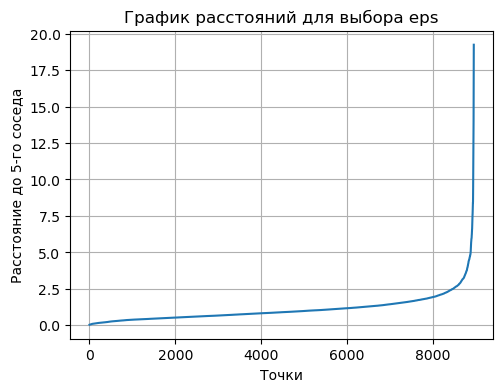

In [148]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(distances)
plt.title('График расстояний для выбора eps')
plt.xlabel('Точки')
plt.ylabel('Расстояние до 5-го соседа')
plt.grid(True)

In [149]:
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=2.0, min_samples=5) #eps - радиус, min_samples - минимальный размер кластера
dbscan_labels = dbscan.fit_predict(X_scaled)
print(f"Найдено кластеров: {len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)}")
print(f"Шумовых точек: {list(dbscan_labels).count(-1)}")

Найдено кластеров: 2
Шумовых точек: 599


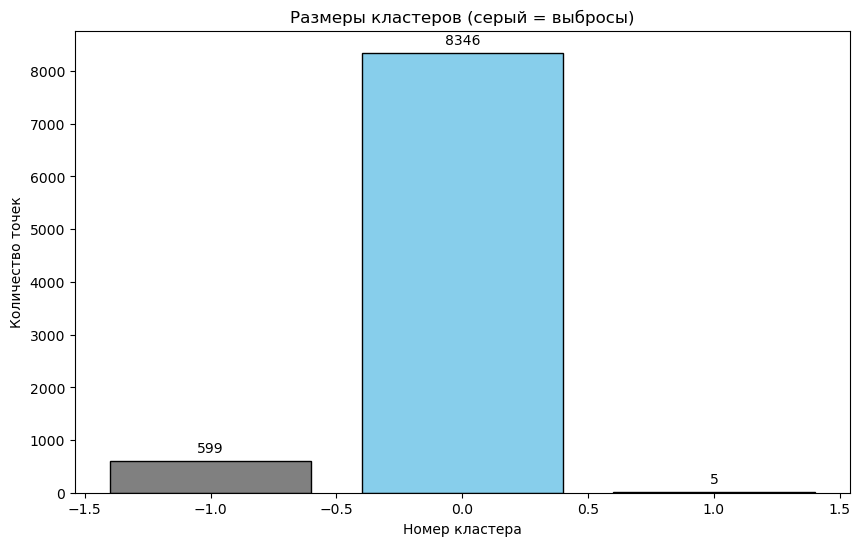

In [150]:
cluster_counts_db = pd.Series(dbscan_labels).value_counts().sort_index()
plt.figure(figsize=(10, 6))
colors = ['gray' if idx == -1 else 'skyblue' for idx in cluster_counts_db.index]
plt.bar(cluster_counts_db.index, cluster_counts_db.values, color=colors, edgecolor='black')
plt.title('Размеры кластеров (серый = выбросы)')
plt.xlabel('Номер кластера')
plt.ylabel('Количество точек')
for i, v in enumerate(cluster_counts_db.values):
    plt.text(cluster_counts_db.index[i], v + max(cluster_counts_db.values)*0.02, str(v), ha='center')
plt.show()

In [151]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
df['DBSCAN'] = dbscan.fit_predict(X_scaled)
labels = dbscan.labels_
df['cluster'] = dbscan.labels_
n_ = list(df['DBSCAN']).count(-1)
print(n_)
print(df.head())

1320
       BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  \
0    40.900749           0.818182      95.40              0.00   
1  3202.467416           0.909091       0.00              0.00   
2  2495.148862           1.000000     773.17            773.17   
3  1666.670542           0.636364    1499.00           1499.00   
4   817.714335           1.000000      16.00             16.00   

   INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
0                    95.4      0.000000             0.166667   
1                     0.0   6442.945483             0.000000   
2                     0.0      0.000000             1.000000   
3                     0.0    205.788017             0.083333   
4                     0.0      0.000000             0.083333   

   ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
0                    0.000000                          0.083333   
1                    0.000000                          0.000000   
2           

In [152]:
#оценка точности
mask = dbscan_labels != -1
if mask.sum() > 1:
    score = silhouette_score(X_scaled[mask], dbscan_labels[mask])
    print(f"Silhouette Score: {score:.3f}")
    # Чем ближе к 1, тем лучше

Silhouette Score: 0.446


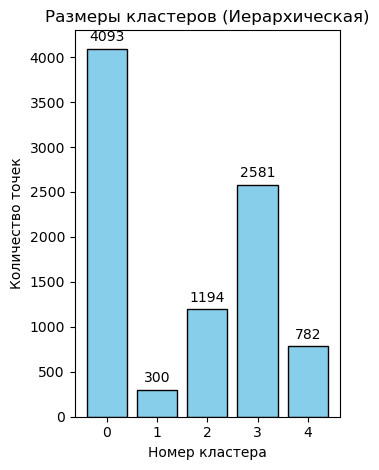

In [153]:
# иерархическая кластеризация
hierarchical = AgglomerativeClustering(n_clusters=5, linkage='ward')
hierarchical_labels = hierarchical.fit_predict(X_scaled)

cluster_counts_hier = pd.Series(hierarchical_labels).value_counts().sort_index()

plt.subplot(1, 2, 2)
colors = ['skyblue' for _ in cluster_counts_hier.index]
plt.bar(cluster_counts_hier.index, cluster_counts_hier.values, color=colors, edgecolor='black')
plt.title('Размеры кластеров (Иерархическая)')
plt.xlabel('Номер кластера')
plt.ylabel('Количество точек')
for i, v in enumerate(cluster_counts_hier.values):
    plt.text(cluster_counts_hier.index[i], v + max(cluster_counts_hier.values)*0.02, str(v), ha='center')
plt.tight_layout()
plt.show()

In [154]:
sil_hier = silhouette_score(X_scaled, hierarchical_labels)

In [155]:
print(sil_hier)

0.1762572355238233


In [156]:
from sklearn.decomposition import PCA

# Инициализация PCA с желаемым количеством компонент
pca = PCA(n_components=2)

# Обучение модели и применение преобразования
X_pca = pca.fit_transform(X_scaled)

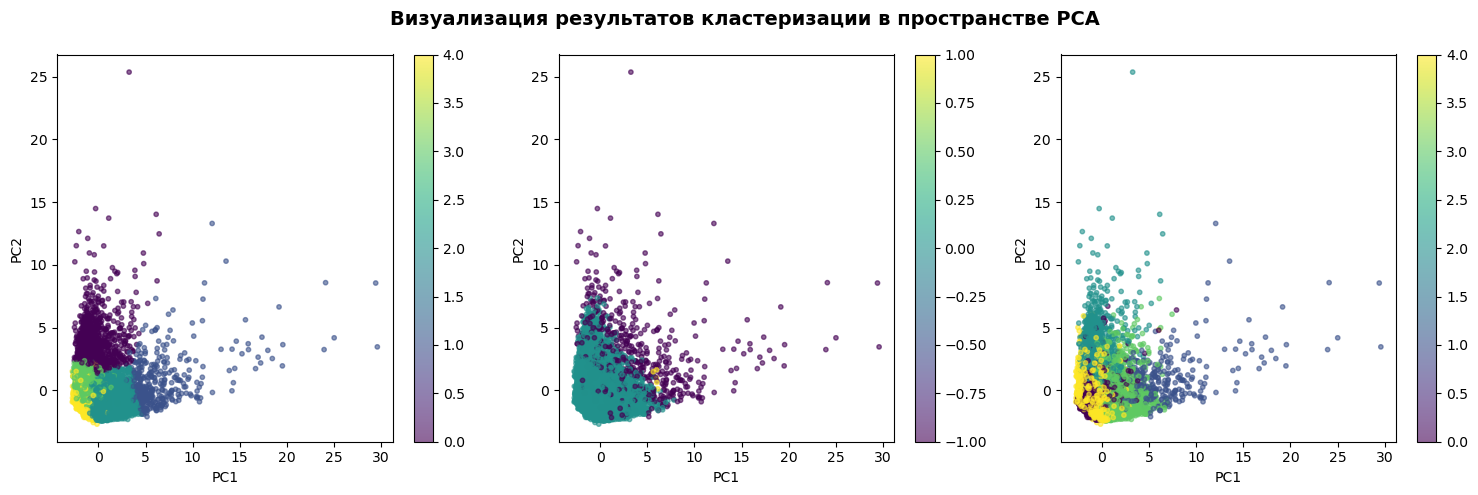

In [157]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# K-Means
scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis', alpha=0.6, s=10)

axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
plt.colorbar(scatter1, ax=axes[0])
# DBSCAN
scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels, cmap='viridis', alpha=0.6, s=10)

axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
plt.colorbar(scatter2, ax=axes[1])

# Иерархическая
scatter3 = axes[2].scatter(X_pca[:, 0], X_pca[:, 1], c=hierarchical_labels, cmap='viridis', alpha=0.6, s=10)

axes[2].set_xlabel('PC1')
axes[2].set_ylabel('PC2')
plt.colorbar(scatter3, ax=axes[2])

plt.suptitle('Визуализация результатов кластеризации в пространстве PCA', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [158]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

#pca = PCA().fit(X_scaled)
# Визуализация
#plt.figure(figsize=(8,6))
#plt.plot(np.cumsum(pca.explained_variance_ratio_))
#plt.xlabel('Number of Components')
#plt.ylabel('Cumulative Explained Variance')
#plt.title('Explained Variance vs. Number of Components')
#plt.grid(True)
#plt.show()

In [159]:
from sklearn.decomposition import PCA

# Инициализация PCA с желаемым количеством компонент
pca = PCA(n_components=2)

# Обучение модели и применение преобразования
X_transformed = pca.fit_transform(X_scaled)

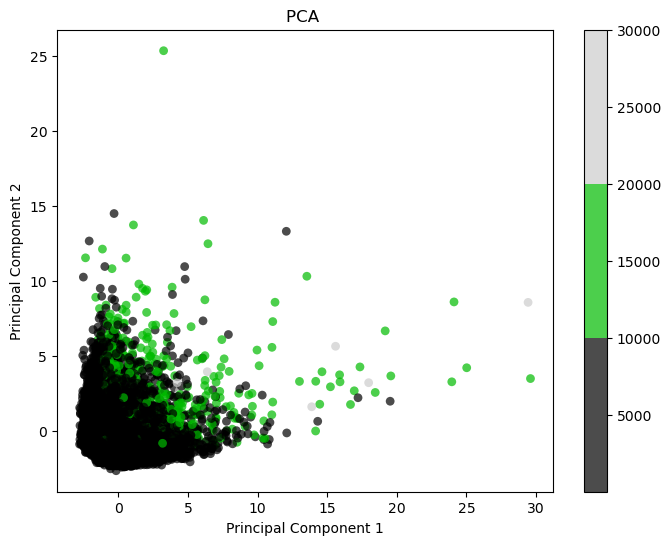

In [160]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
X = df.BALANCE, df.CREDIT_LIMIT
y = df.CREDIT_LIMIT

# Инициализация PCA с 2 компонентами
pca = PCA(n_components=2)

# Применение PCA
X_transformed = pca.fit_transform(X_scaled)

# Визуализация
plt.figure(figsize=(8,6))
plt.scatter(X_transformed[:, 0], X_transformed[:, 1],c = y, edgecolor='none', alpha=0.7, s=40,
            cmap=plt.cm.get_cmap('nipy_spectral', 3))
plt.colorbar()
plt.title('PCA ')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

[4.64060413e+00 3.45334253e+00 1.49824089e+00 1.27151915e+00
 1.05820397e+00 9.75809596e-01 8.30182344e-01 7.30864552e-01
 6.45703978e-01 5.23600386e-01 4.03282677e-01 3.01472838e-01
 2.42735664e-01 1.72153395e-01 2.06876326e-01 4.53959227e-02
 1.16488555e-05] [[-1.01734968e-01 -4.03818730e-01 -1.61631980e-01 -2.79316406e-01
   5.10222490e-02  4.27515633e-02  2.54181627e-01  1.70293511e-01
  -1.28513756e-01 -3.11740599e-02 -1.48486084e-01  4.80669445e-01
  -5.24791875e-01 -2.18911865e-01  1.74537715e-01  5.24974212e-03
  -4.21602874e-05]
 [-1.20490410e-01 -1.31344137e-01 -4.22995451e-01 -1.55761725e-01
  -4.76836195e-01  2.20449530e-02 -1.00800864e-01 -2.83495851e-01
  -6.16254250e-01  8.15805443e-02  1.18901405e-01 -9.13996899e-02
   1.84842432e-01 -4.19293917e-02 -4.11693186e-02  1.08911852e-02
  -7.97922001e-06]
 [-4.11562397e-01 -4.00246231e-02  2.57474232e-01 -4.16208251e-02
   2.78870186e-02  1.80452550e-01 -2.00220478e-01 -2.60546351e-02
  -1.04777325e-01 -5.11626981e-02 -2.0078

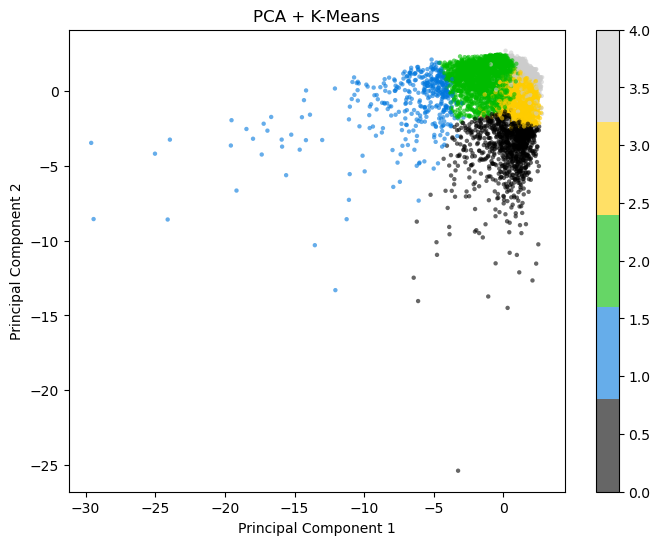

In [161]:
# PCA ручная реализация 
import numpy as np
import numpy as np

# Центрирование данных
X_centered = X_scaled - np.mean(X_scaled, axis=0)

# Вычисление ковариационной матрицы
cov_matrix = np.dot(X_centered.T, X_centered) / X_centered.shape[0]

# Вычисление собственных векторов и значений
eig_vals, eig_vecs = np.linalg.eig(cov_matrix)
print(eig_vals, eig_vecs)

# Сортировка собственных значений и выбор первых k собственных векторов
sorted_idx = np.argsort(eig_vals)[::-1]
X_pca = np.dot(X_centered, eig_vecs[:, sorted_idx[:2]])

# Визуализация
plt.figure(figsize= (8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, edgecolor='none', alpha=0.6, s=10,
cmap=plt.cm.get_cmap('nipy_spectral', 5))
plt.colorbar()
plt.title('PCA + K-Means')
plt.xlabel('Principal Component 1') 
plt.ylabel('Principal Component 2')
plt.show()

In [163]:

df['Cluster_DBSCAN'] = dbscan_labels

for cluster in sorted(set(dbscan_labels)):
    if cluster != -1:
        cluster_data = df[df['Cluster_DBSCAN'] == cluster]
        print(f"\n кластер {cluster} (n={len(cluster_data)}):")
        print(f"   Баланс {cluster_data['BALANCE'].mean():.0f}")
        print(f"   Покупки {cluster_data['PURCHASES'].mean():.0f}")
        print(f"   Кредитный лимит {cluster_data['CREDIT_LIMIT'].mean():.0f}")
        print(f"   Платежи {cluster_data['PAYMENTS'].mean():.0f}")

# Шум
noise_data = df[df['Cluster_DBSCAN'] == -1]
print(f"\n выбросы (n={len(noise_data)}):")



 кластер 0 (n=8346):
   Баланс 1365
   Покупки 739
   Кредитный лимит 4136
   Платежи 1315

 кластер 1 (n=5):
   Баланс 8264
   Покупки 5298
   Кредитный лимит 11720
   Платежи 3626

 выбросы (n=599):
